In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d

Outcome: AMD
Data: GBD 2021
Step: 3. Figure
weze_code_ver

```
step1. Scaling
step2. Scaling factor for number
step3. Figure

In [2]:
# load
pop_df=pd.read_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/population/pop_2050.csv")
forecast_final=pd.read_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/forecast_final_ui.csv") 
number_df=pd.read_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/amd2021/IHME-GBD_2021_DATA-e8837696-1(number).csv") 

In [3]:
# re-log transform
columns_to_reverse = ['mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper', 'finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper']
# expm1 (log1p의 반대 연산)
for col in columns_to_reverse:
    forecast_final[col] = np.expm1(forecast_final[col])
forecast_final

,sex_name,age_name,year,smoke_cate,omega,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper
0,Female,All ages,1990,Mean Per Day,0.0,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795
1,Female,All ages,1991,Mean Per Day,0.0,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199
2,Female,All ages,1992,Mean Per Day,0.0,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900
3,Female,All ages,1993,Mean Per Day,0.0,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793
4,Female,All ages,1994,Mean Per Day,0.0,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613
...,...,...,...,...,...,...,...,...,...,...,...
727,Male,All ages,2046,Mean Per Day,2.5,72.075351,49.204876,105.364308,79.158948,50.083223,124.784095
728,Male,All ages,2047,Mean Per Day,2.5,71.820480,49.029773,104.993333,78.879246,49.904976,124.345191
729,Male,All ages,2048,Mean Per Day,2.5,71.566499,48.855280,104.623652,78.600520,49.727351,123.907818
730,Male,All ages,2049,Mean Per Day,2.5,71.313403,48.681396,104.255260,78.322766,49.550346,123.471972


In [4]:
# omega = 1.0
filtered_forecast = forecast_final[forecast_final['omega'] == 1.0]
filtered_forecast.to_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/filtered_forecast.csv", index=False)
filtered_forecast

,sex_name,age_name,year,smoke_cate,omega,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper
244,Female,All ages,1990,Mean Per Day,1.0,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795
245,Female,All ages,1991,Mean Per Day,1.0,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199
246,Female,All ages,1992,Mean Per Day,1.0,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900
247,Female,All ages,1993,Mean Per Day,1.0,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793
248,Female,All ages,1994,Mean Per Day,1.0,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613
...,...,...,...,...,...,...,...,...,...,...,...
361,Male,All ages,2046,Mean Per Day,1.0,106.312109,72.726517,155.197378,117.419777,74.465859,184.822354
362,Male,All ages,2047,Mean Per Day,1.0,107.142545,73.297051,156.406113,118.343055,75.054240,186.271146
363,Male,All ages,2048,Mean Per Day,1.0,107.979407,73.871999,157.624202,119.273531,75.647209,187.731234
364,Male,All ages,2049,Mean Per Day,1.0,108.822745,74.451397,158.851717,120.211262,76.244800,189.202705


In [5]:
# number
# pop-prediction rate
pop_df = pop_df[['location_name', 'sex_name', 'age_name', 'year', 'pop_val']]
filtered_pop_df = pop_df[
    (pop_df['location_name'] == 'Global') & 
    (pop_df['age_name'] == 'All ages') & 
    (pop_df['year'] >= 1990)
]
filtered_pop_df = filtered_pop_df[['location_name', 'sex_name', 'age_name', 'year', 'pop_val']]

# merge rate and population
rate_data = filtered_forecast[
    ["year", "sex_name", "age_name", 
     "finalprev_arc_ensemble", "finalprev_arc_ensemble_lower", "finalprev_arc_ensemble_upper",
     "mrbrt_arc_ensemble", "mrbrt_arc_ensemble_lower", "mrbrt_arc_ensemble_upper"]
]
population_data = filtered_pop_df[["year", "sex_name", "age_name", "pop_val"]]
merged_data = pd.merge(rate_data, population_data, how="inner", on=["year", "sex_name", "age_name"])

# calculate
merged_data["number_finalprev"] = (merged_data["finalprev_arc_ensemble"] / 100000) * merged_data["pop_val"]
merged_data["number_finalprev_lower"] = (merged_data["finalprev_arc_ensemble_lower"] / 100000) * merged_data["pop_val"]
merged_data["number_finalprev_upper"] = (merged_data["finalprev_arc_ensemble_upper"] / 100000) * merged_data["pop_val"]
merged_data["number_mrbrt"] = (merged_data["mrbrt_arc_ensemble"] / 100000) * merged_data["pop_val"]
merged_data["number_mrbrt_lower"] = (merged_data["mrbrt_arc_ensemble_lower"] / 100000) * merged_data["pop_val"]
merged_data["number_mrbrt_upper"] = (merged_data["mrbrt_arc_ensemble_upper"] / 100000) * merged_data["pop_val"]
merged_data


,year,sex_name,age_name,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,pop_val,number_finalprev,number_finalprev_lower,number_finalprev_upper,number_mrbrt,number_mrbrt_lower,number_mrbrt_upper
0,1990,Female,All ages,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795,5.825324e+08,4.710189e+05,3.619992e+05,6.123511e+05,4.710189e+05,3.619992e+05,6.123511e+05
1,1991,Female,All ages,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199,5.928578e+08,4.878436e+05,3.749537e+05,6.341930e+05,4.878436e+05,3.749537e+05,6.341930e+05
2,1992,Female,All ages,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900,6.054258e+08,5.058243e+05,3.887947e+05,6.575403e+05,5.058243e+05,3.887947e+05,6.575403e+05
3,1993,Female,All ages,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793,6.178148e+08,5.229228e+05,4.019557e+05,6.797433e+05,5.229228e+05,4.019557e+05,6.797433e+05
4,1994,Female,All ages,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613,6.317656e+08,5.405584e+05,4.155275e+05,7.026473e+05,5.405584e+05,4.155275e+05,7.026473e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2046,Male,All ages,117.419777,74.465859,184.822354,106.312109,72.726517,155.197378,1.776266e+09,2.085688e+06,1.322712e+06,3.282938e+06,1.888386e+06,1.291817e+06,2.756719e+06
118,2047,Male,All ages,118.343055,75.054240,186.271146,107.142545,73.297051,156.406113,1.796204e+09,2.125683e+06,1.348127e+06,3.345810e+06,1.924499e+06,1.316565e+06,2.809373e+06
119,2048,Male,All ages,119.273531,75.647209,187.731234,107.979407,73.871999,157.624202,1.815981e+09,2.165984e+06,1.373739e+06,3.409163e+06,1.960885e+06,1.341501e+06,2.862425e+06
120,2049,Male,All ages,120.211262,76.244800,189.202705,108.822745,74.451397,158.851717,1.835686e+09,2.206702e+06,1.399615e+06,3.473168e+06,1.997644e+06,1.366694e+06,2.916019e+06


In [6]:
# 1990-2021 num
number_df = number_df[['location_name', 'sex_name', 'age_name', 'year', 'val', 'lower','upper']]
filtered_num = number_df[
    (number_df['location_name'] == 'Global') & 
    (number_df['age_name'] == 'All ages') & 
    (number_df['year'] >= 1990)
]
filtered_num

,location_name,sex_name,age_name,year,val,lower,upper
64,Global,Male,All ages,1990,1.499180e+06,1.245793e+06,1.812002e+06
65,Global,Female,All ages,1990,2.141000e+06,1.787369e+06,2.536951e+06
66,Global,Male,All ages,1991,1.545465e+06,1.281513e+06,1.867872e+06
67,Global,Female,All ages,1991,2.211822e+06,1.846862e+06,2.622668e+06
68,Global,Male,All ages,1992,1.590806e+06,1.316161e+06,1.923299e+06
...,...,...,...,...,...,...,...
123,Global,Female,All ages,2019,4.407255e+06,3.676914e+06,5.350351e+06
124,Global,Male,All ages,2020,3.425540e+06,2.818177e+06,4.180787e+06
125,Global,Female,All ages,2020,4.609706e+06,3.850107e+06,5.592603e+06
126,Global,Male,All ages,2021,3.399691e+06,2.808352e+06,4.167120e+06


In [7]:
merged_actual = pd.merge(
    merged_data, 
    filtered_num, 
    how="left", 
    on=["year", "age_name", "sex_name"]
)
merged_actual

,year,sex_name,age_name,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,pop_val,number_finalprev,number_finalprev_lower,number_finalprev_upper,number_mrbrt,number_mrbrt_lower,number_mrbrt_upper,location_name,val,lower,upper
0,1990,Female,All ages,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795,5.825324e+08,4.710189e+05,3.619992e+05,6.123511e+05,4.710189e+05,3.619992e+05,6.123511e+05,Global,2.141000e+06,1.787369e+06,2.536951e+06
1,1991,Female,All ages,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199,5.928578e+08,4.878436e+05,3.749537e+05,6.341930e+05,4.878436e+05,3.749537e+05,6.341930e+05,Global,2.211822e+06,1.846862e+06,2.622668e+06
2,1992,Female,All ages,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900,6.054258e+08,5.058243e+05,3.887947e+05,6.575403e+05,5.058243e+05,3.887947e+05,6.575403e+05,Global,2.278423e+06,1.904449e+06,2.703585e+06
3,1993,Female,All ages,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793,6.178148e+08,5.229228e+05,4.019557e+05,6.797433e+05,5.229228e+05,4.019557e+05,6.797433e+05,Global,2.340534e+06,1.958100e+06,2.777208e+06
4,1994,Female,All ages,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613,6.317656e+08,5.405584e+05,4.155275e+05,7.026473e+05,5.405584e+05,4.155275e+05,7.026473e+05,Global,2.397651e+06,2.007680e+06,2.843446e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2046,Male,All ages,117.419777,74.465859,184.822354,106.312109,72.726517,155.197378,1.776266e+09,2.085688e+06,1.322712e+06,3.282938e+06,1.888386e+06,1.291817e+06,2.756719e+06,NaN,NaN,NaN,NaN
118,2047,Male,All ages,118.343055,75.054240,186.271146,107.142545,73.297051,156.406113,1.796204e+09,2.125683e+06,1.348127e+06,3.345810e+06,1.924499e+06,1.316565e+06,2.809373e+06,NaN,NaN,NaN,NaN
119,2048,Male,All ages,119.273531,75.647209,187.731234,107.979407,73.871999,157.624202,1.815981e+09,2.165984e+06,1.373739e+06,3.409163e+06,1.960885e+06,1.341501e+06,2.862425e+06,NaN,NaN,NaN,NaN
120,2049,Male,All ages,120.211262,76.244800,189.202705,108.822745,74.451397,158.851717,1.835686e+09,2.206702e+06,1.399615e+06,3.473168e+06,1.997644e+06,1.366694e+06,2.916019e+06,NaN,NaN,NaN,NaN


In [8]:
# Scaling factor: actual / prediction value (appendix)
def calculate_scaling_factors(data, actual_col, pred_col, pred_lower_col, pred_upper_col, year_range):
    start_year, end_year = year_range
    years_to_match = (data['year'] >= start_year) & (data['year'] <= end_year)

    data[f'scaling_factor_{pred_col}'] = (data.loc[years_to_match, actual_col] / data.loc[years_to_match, pred_col]).fillna(1)
    data[f'scaling_factor_{pred_col}_lower'] = (data.loc[years_to_match, actual_col] / data.loc[years_to_match, pred_upper_col]).fillna(1)
    data[f'scaling_factor_{pred_col}_upper'] = (data.loc[years_to_match, actual_col] / data.loc[years_to_match, pred_lower_col]).fillna(1)

    avg_scaling_factors = {
        "mean": data.loc[years_to_match, f'scaling_factor_{pred_col}'].mean(),
        "lower": data.loc[years_to_match, f'scaling_factor_{pred_col}_lower'].mean(),
        "upper": data.loc[years_to_match, f'scaling_factor_{pred_col}_upper'].mean(),
    }

    return avg_scaling_factors

# finalprev_arc_ensemble
finalprev_scaling_factors = calculate_scaling_factors(
    data=merged_actual,
    actual_col='val',
    pred_col='number_finalprev',
    pred_lower_col='number_finalprev_lower',
    pred_upper_col='number_finalprev_upper',
    year_range=(1990, 2021)
)
# mrbrt_arc_ensemble
mrbrt_scaling_factors = calculate_scaling_factors(
    data=merged_actual,
    actual_col='val',
    pred_col='number_mrbrt',
    pred_lower_col='number_mrbrt_lower',
    pred_upper_col='number_mrbrt_upper',
    year_range=(1990, 2021)
)

In [9]:
def apply_scaling_factors(data, future_years, years_to_match, scaling_factors, prefix):
    # mean scaling
    data.loc[future_years, f'scaled_{prefix}'] = (
        data.loc[future_years, f'number_{prefix}'] * scaling_factors["mean"]
    )
    data.loc[years_to_match, f'scaled_{prefix}'] = data.loc[years_to_match, 'val']  # 실제 값 유지
    # lower scaling
    data.loc[future_years, f'scaled_{prefix}_lower'] = (
        data.loc[future_years, f'number_{prefix}_lower'] * scaling_factors["mean"]
    )
    data.loc[years_to_match, f'scaled_{prefix}_lower'] = data.loc[years_to_match, 'lower']  # 실제 값 유지
    # upper scaling
    data.loc[future_years, f'scaled_{prefix}_upper'] = (
        data.loc[future_years, f'number_{prefix}_upper'] * scaling_factors["mean"]
    )
    data.loc[years_to_match, f'scaled_{prefix}_upper'] = data.loc[years_to_match, 'upper']  # 실제 값 유지

    return data

future_years = (merged_actual['year'] >= 2022)
years_to_match = (merged_actual['year'] >= 1990) & (merged_actual['year'] <= 2021)

# finalprev
merged_actual = apply_scaling_factors(
    data=merged_actual,
    future_years=future_years,
    years_to_match=years_to_match,
    scaling_factors=finalprev_scaling_factors,
    prefix="finalprev"
)
# mrbrt
merged_actual = apply_scaling_factors(
    data=merged_actual,
    future_years=future_years,
    years_to_match=years_to_match,
    scaling_factors=mrbrt_scaling_factors,
    prefix="mrbrt"
)

In [10]:
forcast_num = merged_actual[[
    'year', 'age_name', 'sex_name', 
    'scaled_finalprev', 'scaled_finalprev_lower', 'scaled_finalprev_upper',
    'scaled_mrbrt', 'scaled_mrbrt_lower', 'scaled_mrbrt_upper'
]]
forcast_num.to_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/forcast_num.csv", index=False)
forcast_num

,year,age_name,sex_name,scaled_finalprev,scaled_finalprev_lower,scaled_finalprev_upper,scaled_mrbrt,scaled_mrbrt_lower,scaled_mrbrt_upper
0,1990,All ages,Female,2.141000e+06,1.787369e+06,2.536951e+06,2.141000e+06,1.787369e+06,2.536951e+06
1,1991,All ages,Female,2.211822e+06,1.846862e+06,2.622668e+06,2.211822e+06,1.846862e+06,2.622668e+06
2,1992,All ages,Female,2.278423e+06,1.904449e+06,2.703585e+06,2.278423e+06,1.904449e+06,2.703585e+06
3,1993,All ages,Female,2.340534e+06,1.958100e+06,2.777208e+06,2.340534e+06,1.958100e+06,2.777208e+06
4,1994,All ages,Female,2.397651e+06,2.007680e+06,2.843446e+06,2.397651e+06,2.007680e+06,2.843446e+06
...,...,...,...,...,...,...,...,...,...
117,2046,All ages,Male,8.371919e+06,5.309346e+06,1.317766e+07,7.579953e+06,5.185332e+06,1.106543e+07
118,2047,All ages,Male,8.532458e+06,5.411362e+06,1.343003e+07,7.724908e+06,5.284670e+06,1.127678e+07
119,2048,All ages,Male,8.694227e+06,5.514166e+06,1.368433e+07,7.870962e+06,5.384765e+06,1.148973e+07
120,2049,All ages,Male,8.857666e+06,5.618034e+06,1.394124e+07,8.018513e+06,5.485889e+06,1.170486e+07


Mrbrt-ARC-PAF ensemble (total)

In [11]:
# Separate male and female data
male_data = forcast_num[forcast_num['sex_name'] == 'Male']
female_data = forcast_num[forcast_num['sex_name'] == 'Female']

# Gaussian_smoothing
def apply_gaussian_smoothing_in_range(data, column, start_year, end_year, sigma):
    subset = data[(data['year'] >= start_year) & (data['year'] <= end_year)]
    smoothed_values = gaussian_filter1d(subset[column], sigma)
    data.loc[(data['year'] >= start_year) & (data['year'] <= end_year), column] = smoothed_values
    return data

def preprocess_data(data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma):
    for column in columns_to_smooth:
        data = apply_gaussian_smoothing_in_range(data, column, smoothing_start_year, smoothing_end_year, sigma)
    before_2021 = data[data['year'] <= 2021]
    after_2021 = data[data['year'] > 2021]
    return before_2021, after_2021

In [12]:
# millions
def convert_to_millions(data, columns):
    data = data.copy()
    for column in columns:
        data[column] /= 1e6
    return data

In [13]:
# Plot (male/female)
def plot_male_female_forecast_in_million(
    male_before, male_after, female_before, female_after, 
    y_column, lower_column, upper_column, title="", save_path=None
):
    #  million scale
    columns_to_convert = [y_column, lower_column, upper_column]
    male_before = convert_to_millions(male_before, columns_to_convert)
    male_after = convert_to_millions(male_after, columns_to_convert)
    female_before = convert_to_millions(female_before, columns_to_convert)
    female_after = convert_to_millions(female_after, columns_to_convert)

    y_min = min(male_before[lower_column].min(), female_before[lower_column].min())
    y_max = max(male_after[upper_column].max(), female_after[upper_column].max())

    plt.figure(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'
    ax = plt.gca()
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Male
    plt.plot(male_before['year'], male_before[y_column], '-', color='royalblue', label='GBD 2021 estimates: male')
    plt.plot(male_after['year'], male_after[y_column], '--', color='royalblue', label='Forecasted estimates: male')
    plt.fill_between(
        pd.concat([male_before, male_after])['year'],
        pd.concat([male_before, male_after])[lower_column],
        pd.concat([male_before, male_after])[upper_column],
        alpha=0.2, color='royalblue'
    )
    # Female
    plt.plot(female_before['year'], female_before[y_column], '-', color='darkorange', label='GBD 2021 estimates: female')
    plt.plot(female_after['year'], female_after[y_column], '--', color='darkorange', label='Forecasted estimates: female')
    plt.fill_between(
        pd.concat([female_before, female_after])['year'],
        pd.concat([female_before, female_after])[lower_column],
        pd.concat([female_before, female_after])[upper_column],
        alpha=0.2, color='darkorange'
    )
    plt.xlabel('Year', fontsize=18)
    plt.ylabel('Number of cases (million)', fontsize=18)
    plt.xticks(np.arange(1990, 2051, 10))
    plt.xlim(1990, 2050)
    plt.ylim(0, 18)
    plt.tick_params(axis='y', labelsize=15)
    plt.tick_params(axis='x', labelsize=15)

    plt.legend(loc='upper left', frameon=False, fontsize=14)
    plt.title(title, fontsize=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1000, bbox_inches='tight') 
    plt.show()

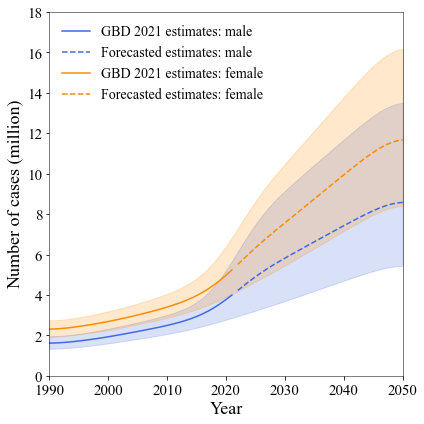

In [17]:
columns_to_smooth = ['scaled_finalprev', 'scaled_finalprev_lower', 'scaled_finalprev_upper']
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 2.0

# Male
male_before, male_after = preprocess_data(
    male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value
)
# Female 
female_before, female_after = preprocess_data(
    female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value
)

save_path = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\2.revision\prediction_model\prediction_figure\forecast_graph_million_both_.png"
plot_male_female_forecast_in_million(
    male_before=male_before,
    male_after=male_after,
    female_before=female_before,
    female_after=female_after,
    y_column='scaled_finalprev',
    lower_column='scaled_finalprev_lower',
    upper_column='scaled_finalprev_upper',
    save_path=save_path
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


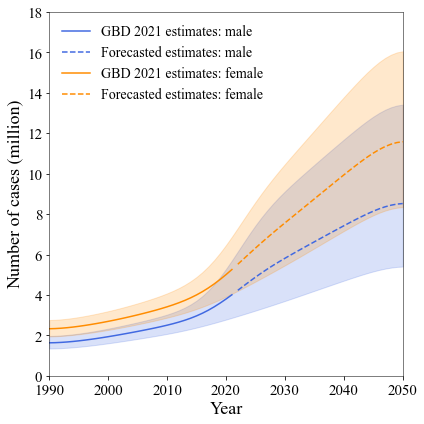

✅ 파일 저장 완료:
C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\figure5.png
C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\figure5.eps
C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\figure5.pdf


In [18]:
# 0217
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 저장 경로 설정
output_dir = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector"
os.makedirs(output_dir, exist_ok=True)  # 폴더가 없으면 생성

output_path_png = os.path.join(output_dir, "figure5.png")
output_path_eps = os.path.join(output_dir, "figure5.eps")
output_path_pdf = os.path.join(output_dir, "figure5.pdf")

# 📌 플롯 함수 수정 (EPS, PDF 저장 추가)
def plot_male_female_forecast_in_million(
    male_before, male_after, female_before, female_after, 
    y_column, lower_column, upper_column, title="", save_path=None
):
    #  million scale 변환
    columns_to_convert = [y_column, lower_column, upper_column]
    male_before = convert_to_millions(male_before, columns_to_convert)
    male_after = convert_to_millions(male_after, columns_to_convert)
    female_before = convert_to_millions(female_before, columns_to_convert)
    female_after = convert_to_millions(female_after, columns_to_convert)

    y_min = min(male_before[lower_column].min(), female_before[lower_column].min())
    y_max = max(male_after[upper_column].max(), female_after[upper_column].max())

    # 📌 플롯 생성
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Male
    ax.plot(male_before['year'], male_before[y_column], '-', color='royalblue', label='GBD 2021 estimates: male')
    ax.plot(male_after['year'], male_after[y_column], '--', color='royalblue', label='Forecasted estimates: male')
    ax.fill_between(
        pd.concat([male_before, male_after])['year'],
        pd.concat([male_before, male_after])[lower_column],
        pd.concat([male_before, male_after])[upper_column],
        alpha=0.2, color='royalblue'
    )
    # Female
    ax.plot(female_before['year'], female_before[y_column], '-', color='darkorange', label='GBD 2021 estimates: female')
    ax.plot(female_after['year'], female_after[y_column], '--', color='darkorange', label='Forecasted estimates: female')
    ax.fill_between(
        pd.concat([female_before, female_after])['year'],
        pd.concat([female_before, female_after])[lower_column],
        pd.concat([female_before, female_after])[upper_column],
        alpha=0.2, color='darkorange'
    )

    ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Number of cases (million)', fontsize=18)
    ax.set_xticks(np.arange(1990, 2051, 10))
    ax.set_xlim(1990, 2050)
    ax.set_ylim(0, 18)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)

    ax.legend(loc='upper left', frameon=False, fontsize=14)
    ax.set_title(title, fontsize=20)

    plt.tight_layout()

    # 📌 저장 경로 설정
    if save_path:
        fig.savefig(save_path, format='png', dpi=1000, bbox_inches='tight')  # PNG 저장
        fig.savefig(output_path_eps, format='eps', dpi=1000, bbox_inches='tight')  # EPS 저장
        fig.savefig(output_path_pdf, format='pdf', dpi=1000, bbox_inches='tight')  # PDF 저장

    plt.show()

# 📌 데이터 처리
columns_to_smooth = ['scaled_finalprev', 'scaled_finalprev_lower', 'scaled_finalprev_upper']
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 2.0

# Male
male_before, male_after = preprocess_data(
    male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value
)
# Female 
female_before, female_after = preprocess_data(
    female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value
)

# 📌 그래프 저장 실행
plot_male_female_forecast_in_million(
    male_before=male_before,
    male_after=male_after,
    female_before=female_before,
    female_after=female_after,
    y_column='scaled_finalprev',
    lower_column='scaled_finalprev_lower',
    upper_column='scaled_finalprev_upper',
    save_path=output_path_png  # PNG 저장 (함수 내에서 EPS, PDF도 저장됨)
)

print(f"✅ 파일 저장 완료:\n{output_path_png}\n{output_path_eps}\n{output_path_pdf}")


sex-split
male colors = ['#3ec1d5', 'royalblue']
female colors = ['#ffb700', '#ff7844']

In [41]:
# Preprocessing and smoothing
def preprocess_data(data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma):
    for column in columns_to_smooth:
        data = apply_gaussian_smoothing_in_range(data, column, smoothing_start_year, smoothing_end_year, sigma)
    before_2021 = data[data['year'] <= 2021]
    after_2021 = data[data['year'] > 2021]
    return before_2021, after_2021

In [42]:
def apply_gaussian_smoothing_in_range(data, column, start_year, end_year, sigma):
    subset = data[(data['year'] >= start_year) & (data['year'] <= end_year)]
    smoothed_values = gaussian_filter1d(subset[column], sigma)
    data.loc[(data['year'] >= start_year) & (data['year'] <= end_year), column] = smoothed_values
    return data

In [43]:
def convert_to_millions(data, columns):
    data = data.copy()
    for column in columns:
        data[column] /= 1e6
    return data

In [46]:
# Plot function for male or female data with custom legend labels
def plot_gender_forecast_in_million(data_before, data_after, y_columns, lower_columns, upper_columns, gender, legend_labels, save_path=None):
    # Scale to millions
    columns_to_convert = y_columns + lower_columns + upper_columns
    data_before = convert_to_millions(data_before, columns_to_convert)
    data_after = convert_to_millions(data_after, columns_to_convert)

    plt.figure(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'
    ax = plt.gca()
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Custom colors for the lines
    colors = ['#ffb700', '#ff7844']
    for i, y_column in enumerate(y_columns):
        # Plot lines
        plt.plot(data_before['year'], data_before[y_column], '-', color=colors[i])
        plt.plot(data_after['year'], data_after[y_column], '--', color=colors[i], label=f'{legend_labels[i]}')
        
        # Plot confidence intervals
        plt.fill_between(
            pd.concat([data_before, data_after])['year'],
            pd.concat([data_before, data_after])[lower_columns[i]],
            pd.concat([data_before, data_after])[upper_columns[i]],
            alpha=0.2, color=colors[i]
        )

    plt.xlabel('Year', fontsize=18)
    plt.ylabel('Number of cases (million)', fontsize=18)
    plt.xticks(np.arange(1990, 2051, 10))
    plt.xlim(1990, 2050)
    plt.ylim(0, 18)
    plt.tick_params(axis='y', labelsize=15)
    plt.tick_params(axis='x', labelsize=15)

    # Custom legend
    plt.legend(loc='upper left', frameon=False, fontsize=14)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1000, bbox_inches='tight') 
    plt.show()

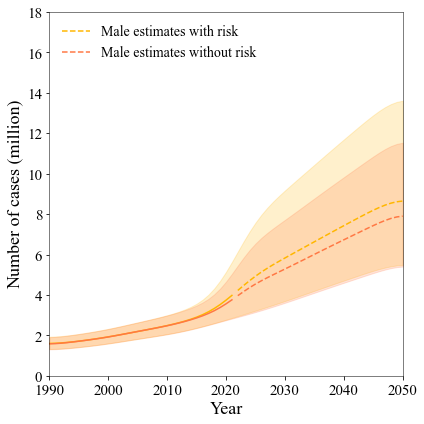

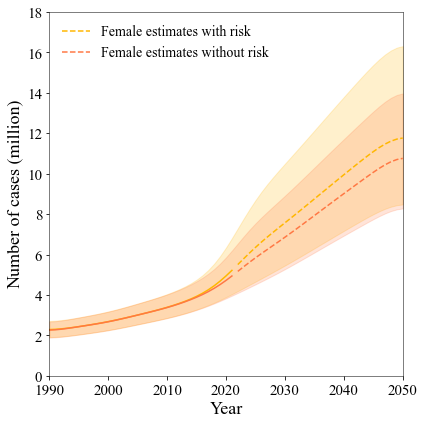

In [47]:
sigma_value = 0.5

# Preprocessing for male data
male_before, male_after = preprocess_data(
    data=male_data,
    columns_to_smooth=['scaled_finalprev', 'scaled_mrbrt', 'scaled_finalprev_lower', 'scaled_mrbrt_lower', 'scaled_finalprev_upper', 'scaled_mrbrt_upper'],  
    smoothing_start_year=1990,
    smoothing_end_year=2050,
    sigma=sigma_value  
)
# Preprocessing for female data
female_before, female_after = preprocess_data(
    data=female_data,
    columns_to_smooth=['scaled_finalprev', 'scaled_mrbrt', 'scaled_finalprev_lower', 'scaled_mrbrt_lower', 'scaled_finalprev_upper', 'scaled_mrbrt_upper'],   
    smoothing_start_year=1990,
    smoothing_end_year=2050,
    sigma=sigma_value  
)

# Plot male data
plot_gender_forecast_in_million(
    data_before=male_before,
    data_after=male_after,
    y_columns=['scaled_finalprev', 'scaled_mrbrt'], 
    lower_columns=['scaled_finalprev_lower', 'scaled_mrbrt_lower'],
    upper_columns=['scaled_finalprev_upper', 'scaled_mrbrt_upper'],
    gender='Male',
    legend_labels=['Male estimates with risk', 'Male estimates without risk'],  
    save_path="male_million_forecast.png"
)
# Plot female data
plot_gender_forecast_in_million(
    data_before=female_before,
    data_after=female_after,
    y_columns=['scaled_finalprev', 'scaled_mrbrt'],  
    lower_columns=['scaled_finalprev_lower', 'scaled_mrbrt_lower'],
    upper_columns=['scaled_finalprev_upper', 'scaled_mrbrt_upper'],
    gender='Female',
    legend_labels=['Female estimates with risk', 'Female estimates without risk'], 
    save_path="female_million_forecast.png"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


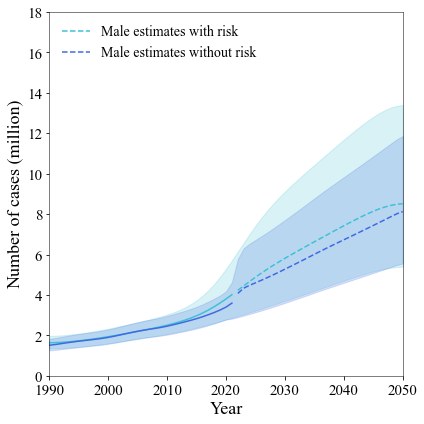

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


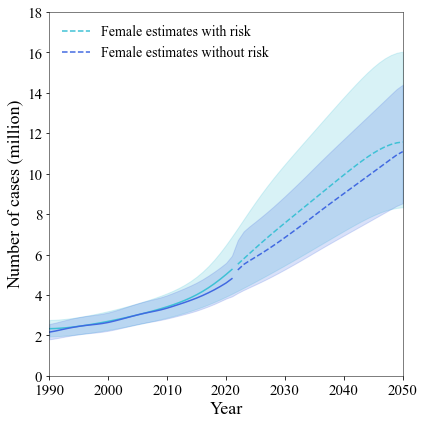

✅ 파일 저장 완료:
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\male_million_forecast.png / .eps / .pdf
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\female_million_forecast.png / .eps / .pdf


In [21]:
#0217
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 저장 경로 설정
output_dir = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector"
os.makedirs(output_dir, exist_ok=True)  # 폴더가 없으면 생성

# 📌 Plot function (EPS, PDF 저장 추가)
def plot_gender_forecast_in_million(data_before, data_after, y_columns, lower_columns, upper_columns, gender, legend_labels, save_path):
    # Scale to millions
    columns_to_convert = y_columns + lower_columns + upper_columns
    data_before = convert_to_millions(data_before, columns_to_convert)
    data_after = convert_to_millions(data_after, columns_to_convert)

    # 📌 플롯 생성
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Custom colors for the lines
    colors = ['#3ec1d5', 'royalblue']
    for i, y_column in enumerate(y_columns):
        # Plot lines
        ax.plot(data_before['year'], data_before[y_column], '-', color=colors[i])
        ax.plot(data_after['year'], data_after[y_column], '--', color=colors[i], label=f'{legend_labels[i]}')
        
        # Plot confidence intervals
        ax.fill_between(
            pd.concat([data_before, data_after])['year'],
            pd.concat([data_before, data_after])[lower_columns[i]],
            pd.concat([data_before, data_after])[upper_columns[i]],
            alpha=0.2, color=colors[i]
        )

    ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Number of cases (million)', fontsize=18)
    ax.set_xticks(np.arange(1990, 2051, 10))
    ax.set_xlim(1990, 2050)
    ax.set_ylim(0, 18)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)

    # Custom legend
    ax.legend(loc='upper left', frameon=False, fontsize=14)
    ax.set_title("", fontsize=20)

    plt.tight_layout()

    # 📌 파일 저장 (PNG, EPS, PDF)
    fig.savefig(save_path + ".png", format='png', dpi=1000, bbox_inches='tight')
    fig.savefig(save_path + ".eps", format='eps', dpi=1000, bbox_inches='tight')
    fig.savefig(save_path + ".pdf", format='pdf', dpi=1000, bbox_inches='tight')

    plt.show()

# 📌 데이터 전처리
sigma_value = 0.5

# Preprocessing for male data
male_before, male_after = preprocess_data(
    data=male_data,
    columns_to_smooth=['scaled_finalprev', 'scaled_mrbrt', 'scaled_finalprev_lower', 'scaled_mrbrt_lower', 'scaled_finalprev_upper', 'scaled_mrbrt_upper'],  
    smoothing_start_year=1990,
    smoothing_end_year=2050,
    sigma=sigma_value  
)
# Preprocessing for female data
female_before, female_after = preprocess_data(
    data=female_data,
    columns_to_smooth=['scaled_finalprev', 'scaled_mrbrt', 'scaled_finalprev_lower', 'scaled_mrbrt_lower', 'scaled_finalprev_upper', 'scaled_mrbrt_upper'],   
    smoothing_start_year=1990,
    smoothing_end_year=2050,
    sigma=sigma_value  
)

# 📌 그래프 저장 실행 (남성)
plot_gender_forecast_in_million(
    data_before=male_before,
    data_after=male_after,
    y_columns=['scaled_finalprev', 'scaled_mrbrt'], 
    lower_columns=['scaled_finalprev_lower', 'scaled_mrbrt_lower'],
    upper_columns=['scaled_finalprev_upper', 'scaled_mrbrt_upper'],
    gender='Male',
    legend_labels=['Male estimates with risk', 'Male estimates without risk'],  
    save_path=os.path.join(output_dir, "male_million_forecast")
)

# 📌 그래프 저장 실행 (여성)
plot_gender_forecast_in_million(
    data_before=female_before,
    data_after=female_after,
    y_columns=['scaled_finalprev', 'scaled_mrbrt'],  
    lower_columns=['scaled_finalprev_lower', 'scaled_mrbrt_lower'],
    upper_columns=['scaled_finalprev_upper', 'scaled_mrbrt_upper'],
    gender='Female',
    legend_labels=['Female estimates with risk', 'Female estimates without risk'], 
    save_path=os.path.join(output_dir, "female_million_forecast")
)

print(f"✅ 파일 저장 완료:\n"
      f"- {output_dir}\\male_million_forecast.png / .eps / .pdf\n"
      f"- {output_dir}\\female_million_forecast.png / .eps / .pdf")


Non-Gaussian smoothing

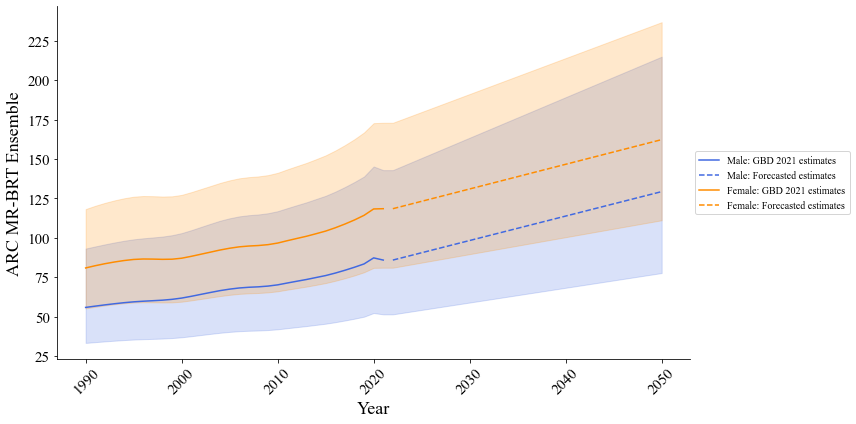

In [159]:
male_data = filtered_forecast[filtered_forecast['sex_name'] == 'Male'].sort_values(by='year').copy()
female_data = filtered_forecast[filtered_forecast['sex_name'] == 'Female'].sort_values(by='year').copy()
male_before = male_data[male_data['year'] <= 2021]
male_after = male_data[male_data['year'] > 2021]
female_before = female_data[female_data['year'] <= 2021]
female_after = female_data[female_data['year'] > 2021]

# 선형 보간법
def linear_transition(before, after, column):
    start_value = before[column].iloc[-1]
    end_value = after[column].iloc[-1]
    after.loc[:, column] = np.linspace(start_value, end_value, len(after))

columns_to_adjust = ['mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper']
for column in columns_to_adjust:
    linear_transition(male_before, male_after, column)
    linear_transition(female_before, female_after, column)

y_min = min(male_before['mrbrt_arc_ensemble_lower'].min(), female_before['mrbrt_arc_ensemble_lower'].min())
y_max = max(male_after['mrbrt_arc_ensemble_upper'].max(), female_after['mrbrt_arc_ensemble_upper'].max())

plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Male
plt.plot(male_before['year'], male_before['mrbrt_arc_ensemble'], '-', color='royalblue', label='Male: GBD 2021 estimates')
plt.plot(male_after['year'], male_after['mrbrt_arc_ensemble'], '--', color='royalblue', label='Male: Forecasted estimates')
plt.fill_between(
    pd.concat([male_before, male_after])['year'],
    pd.concat([male_before, male_after])['mrbrt_arc_ensemble_lower'],
    pd.concat([male_before, male_after])['mrbrt_arc_ensemble_upper'],
    alpha=0.2, color='royalblue'
)
# Female
plt.plot(female_before['year'], female_before['mrbrt_arc_ensemble'], '-', color='darkorange', label='Female: GBD 2021 estimates')
plt.plot(female_after['year'], female_after['mrbrt_arc_ensemble'], '--', color='darkorange', label='Female: Forecasted estimates')
plt.fill_between(
    pd.concat([female_before, female_after])['year'],
    pd.concat([female_before, female_after])['mrbrt_arc_ensemble_lower'],
    pd.concat([female_before, female_after])['mrbrt_arc_ensemble_upper'],
    alpha=0.2, color='darkorange'
)

plt.xlabel('Year', fontsize=18)
plt.ylabel('ARC MR-BRT Ensemble', fontsize=18)
plt.xticks(np.arange(1990, 2051, 10), rotation=45)
plt.ylim(y_min - 10, y_max + 10)  # y축 범위 조정
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()